In [1]:
import pandas as pd
import numpy as np
import joblib
import statsmodels.api as sm    
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy import stats
import sys, os
sys.path.insert(0, os.path.expanduser('~/my_ukb_thesis'))
from const_paths import SAVE_DIR

In [2]:
data_dir = SAVE_DIR
target_col = 'def_CVD_AF_HF_AFTER'

continuous_cols = ['age_defined_baseline', 'BMI', 'sleep_hrs']  
binary_cols = ['genetic_sex', 'mental_doctor', 'uni_degree',
            'FH_cvd_f', 'FH_cvd_m', 'FH_cvd_sib',
            'smk_prev', 'smk_curr', 'alc_curr', 'PA_active']
final_features = continuous_cols + binary_cols

df_B = pd.read_parquet(os.path.join(data_dir, 'split_B_train.parquet')) 
df_C = pd.read_parquet(os.path.join(data_dir, 'split_C_test.parquet'))

X_B_raw, Y_B = df_B[final_features], df_B[target_col]
X_C_raw, Y_C = df_C[final_features], df_C[target_col]

In [3]:
# Single imputation using IterativeImputer
imputer = IterativeImputer(max_iter=10, random_state=42)
X_B_imp = pd.DataFrame(imputer.fit_transform(X_B_raw), columns=final_features, index=X_B_raw.index)
X_C_imp = pd.DataFrame(imputer.transform(X_C_raw), columns=final_features, index=X_C_raw.index)

for col in binary_cols: # round and clip binary features to ensure they remain 0 or 1 after imputation
    X_B_imp[col] = np.clip(np.round(X_B_imp[col]), 0, 1)
    X_C_imp[col] = np.clip(np.round(X_C_imp[col]), 0, 1)

In [4]:
print('\nMissing rate before imputation in Split B:')
missing_rates = X_B_raw.isnull().mean() * 100
missing_rates_filtered = missing_rates[missing_rates > 0].round(2)
if missing_rates_filtered.empty:
    print('There are no missing values in Split B before imputation.')
else:
    for feature, rate in missing_rates_filtered.items():
        print(f"{feature}: {rate}%")


Missing rate before imputation in Split B:
sleep_hrs: 0.61%
alc_curr: 0.31%


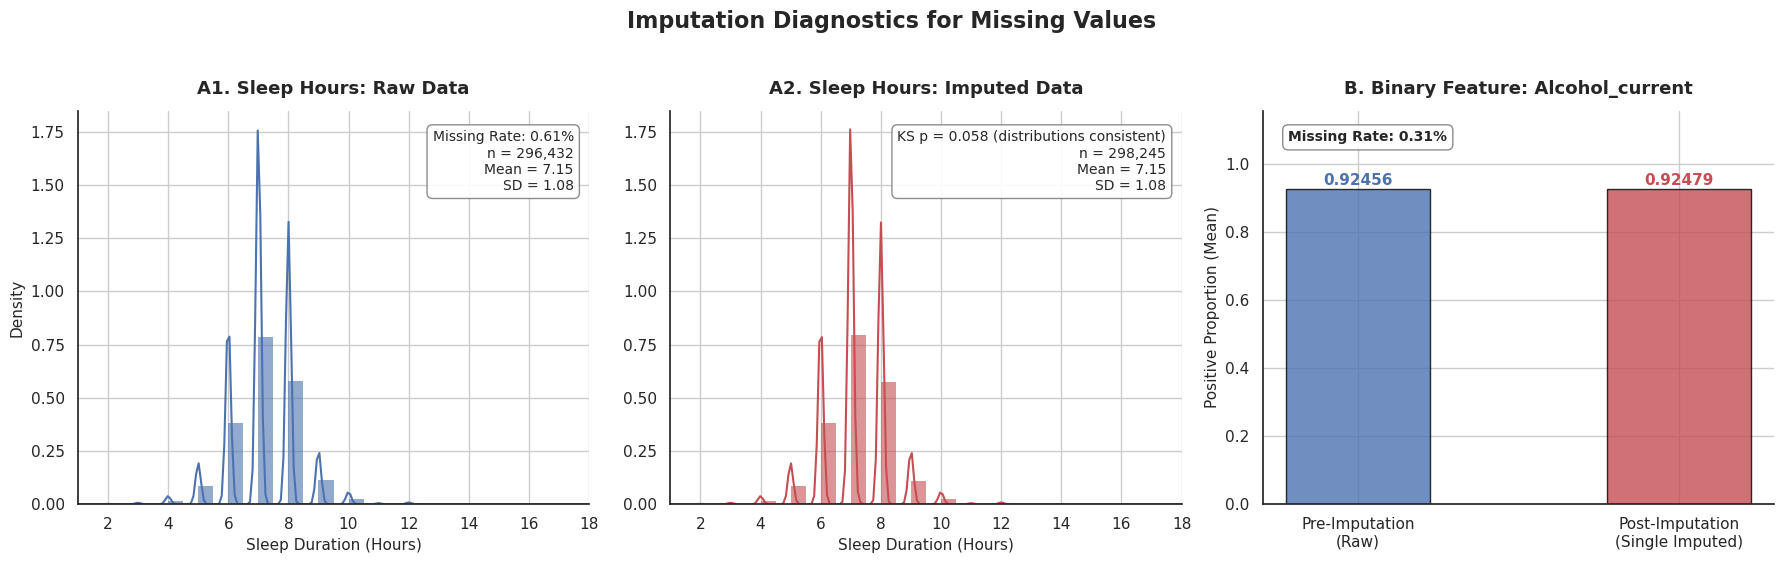

In [5]:
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "0.15", "axes.linewidth": 1.25})

# sleep(raw), sleep(imputed), alcohol_current(raw vs imputed)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))

# continuous variable: sleep_hours (missing 0.61%)
raw_sleep = X_B_raw['sleep_hrs'].dropna()
imp_sleep = X_B_imp['sleep_hrs']

# range of x-axis for both raw and imputed data
x_min = min(raw_sleep.min(), imp_sleep.min())
x_max = max(raw_sleep.max(), imp_sleep.max())
bin_edges = np.arange(x_min, x_max + 0.5, 0.5) # bin width of 0.5 hours

# Plot A1：sleep hours raw data
sns.histplot(raw_sleep, color='#4C72B0', kde=True, stat="density",
            linewidth=0, alpha=0.6, ax=ax1, binrange=(x_min, x_max), bins=bin_edges)
ax1.set_title('A1. Sleep Hours: Raw Data', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Sleep Duration (Hours)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_xlim(x_min, x_max)

# summary statistics for raw data
bbox_props = dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)

legend_raw = (f"Missing Rate: {X_B_raw['sleep_hrs'].isna().mean():.2%}\n"
              f"n = {len(raw_sleep):,}\n"
              f"Mean = {raw_sleep.mean():.2f}\n"
              f"SD = {raw_sleep.std():.2f}")
ax1.text(0.97, 0.95, legend_raw, transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=bbox_props)


# Plot A2：sleep hours imputed data
sns.histplot(imp_sleep, color='#C44E52', kde=True, stat="density",
            linewidth=0, alpha=0.6, ax=ax2, binrange=(x_min, x_max), bins=bin_edges)
ax2.set_title('A2. Sleep Hours: Imputed Data', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Sleep Duration (Hours)', fontsize=11)
ax2.set_ylabel('')
ax2.set_xlim(x_min, x_max)

# KS test
ks_stat, ks_p = stats.ks_2samp(raw_sleep, imp_sleep)
# summary statistics for imputed data
legend_imp = (f"KS p = {ks_p:.3f} (distributions consistent)\n"
              f"n = {len(imp_sleep):,}\n"
              f"Mean = {imp_sleep.mean():.2f}\n"
              f"SD = {imp_sleep.std():.2f}")
ax2.text(0.97, 0.95, legend_imp, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=bbox_props)

# synchronize y-axis limits for raw and imputed sleep hours
ax1.sharey(ax2)
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(0, y_max)
ax2.set_ylim(0, y_max)

# Plot B：Binary variable
raw_alc = X_B_raw['alc_curr'].dropna().mean()
imp_alc = X_B_imp['alc_curr'].mean()

bars = ax3.bar(['Pre-Imputation\n(Raw)', 'Post-Imputation\n(Single Imputed)'],
            [raw_alc, imp_alc],
            color=['#4C72B0', '#C44E52'],
            alpha=0.8, width=0.45, edgecolor='black', linewidth=1)

ax3.set_title('B. Binary Feature: Alcohol current', fontsize=13, fontweight='bold', pad=12)
ax3.set_ylabel('Positive Proportion (Mean)', fontsize=11)
ax3.set_ylim(0, max(raw_alc, imp_alc) * 1.25)

ax3.text(0, raw_alc + 0.005, f'{raw_alc:.5f}', ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#4C72B0')
ax3.text(1, imp_alc + 0.005, f'{imp_alc:.5f}', ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#C44E52')
ax3.text(0.05, 0.95, f"Missing Rate: {X_B_raw['alc_curr'].isna().mean():.2%}",
        transform=ax3.transAxes, fontsize=10, fontweight='bold',
        verticalalignment='top', bbox=bbox_props)

sns.despine(ax=ax1)
sns.despine(ax=ax2)
sns.despine(ax=ax3)

plt.suptitle('Imputation Diagnostics for Missing Values', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

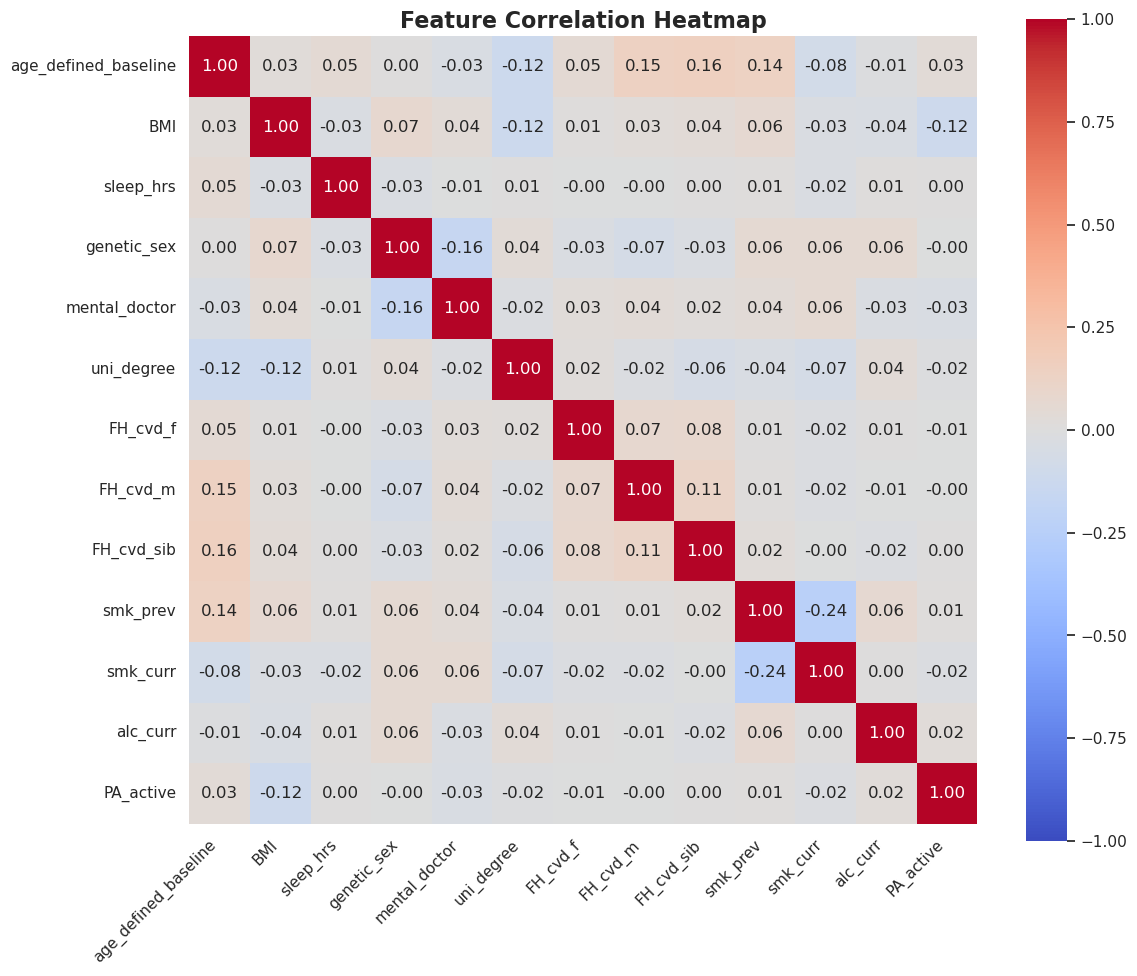

In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = X_B_imp.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True )
plt.title('Feature Correlation Heatmap',fontsize=16, fontweight='bold')
plt.xticks(rotation=45, horizontalalignment='right')
plt.tight_layout()
plt.show()

In [7]:
# Univariate association
print("\nUnivariate Association with Target Variable (CVD_AF_HF_AFTER):")
assoc_df = X_B_imp.copy()
assoc_df['CVD_Outcome'] = Y_B.values
mean_comparison = assoc_df.groupby('CVD_Outcome').mean().T.round(3)
mean_comparison.columns = ['No CVD (0)', 'CVD (1)']
mean_comparison['Absolute Diff'] = abs(mean_comparison['CVD (1)'] - mean_comparison['No CVD (0)'])
print(f"{mean_comparison.sort_values(by='Absolute Diff', ascending=False)}")


Univariate Association with Target Variable (CVD_AF_HF_AFTER):
                      No CVD (0)  CVD (1)  Absolute Diff
age_defined_baseline      55.773   60.716          4.943
BMI                       27.082   28.346          1.264
genetic_sex                0.421    0.595          0.174
uni_degree                 0.341    0.260          0.081
FH_cvd_m                   0.272    0.352          0.080
FH_cvd_sib                 0.116    0.186          0.070
smk_prev                   0.330    0.399          0.069
FH_cvd_f                   0.378    0.428          0.050
smk_curr                   0.100    0.140          0.040
alc_curr                   0.926    0.907          0.019
mental_doctor              0.337    0.356          0.019
PA_active                  0.820    0.802          0.018
sleep_hrs                  7.147    7.152          0.005


In [8]:
# Standardize continuous features
scaler = StandardScaler()
X_B_final = X_B_imp.copy()
X_C_final = X_C_imp.copy()
X_B_final[continuous_cols] = scaler.fit_transform(X_B_imp[continuous_cols])
X_C_final[continuous_cols] = scaler.transform(X_C_imp[continuous_cols])

In [9]:
# Logistic Regression
X_B_sm = sm.add_constant(X_B_final) # add intercept term for statsmodels
X_C_sm = sm.add_constant(X_C_final)

logit_model = sm.Logit(Y_B, X_B_sm).fit(disp=False) # fit logistic regression model on training data
print(logit_model.summary())

print('\n=== (Odds Ratios) ===')
conf = logit_model.conf_int()
conf['OR'] = logit_model.params
conf.columns = ['2.5% CI', '97.5% CI', 'Odds Ratio'] # calculate confidence intervals and odds ratios

result_table = np.exp(conf)
result_table['P-value'] = logit_model.pvalues # add p-values to the result table
print(result_table.sort_values(by='P-value', ascending=True))

                            Logit Regression Results                           
Dep. Variable:     def_CVD_AF_HF_AFTER   No. Observations:               298245
Model:                           Logit   Df Residuals:                   298231
Method:                            MLE   Df Model:                           13
Date:                 Fri, 10 Jul 2026   Pseudo R-squ.:                 0.09124
Time:                         15:03:41   Log-Likelihood:                -80674.
converged:                        True   LL-Null:                       -88774.
Covariance Type:             nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.9369      0.030    -98.941      0.000      -2.995      -2.879
age_defined_baseline     0.7021      0.008     85.239      0.000       0.686       0.718
BMI 

In [10]:
# save model and scaler
save_dir = os.path.join(SAVE_DIR, '../phase_II/outputs')

# 1. Logistic regression model (statsmodels)
logit_model.save(os.path.join(save_dir, 'logistic_model.pkl'))

# 2. StandardScaler (fitted on Split B continuous cols)
joblib.dump(scaler, os.path.join(save_dir, 'logistic_scaler.pkl'))

# 3. Print coefficients as backup (hardcode fallback)
print("=== Coefficients for Phase III ===")
for name, coef in zip(['const'] + final_features, logit_model.params):
    print(f"  {name}: {coef:.6f}")

print("\n=== Scaler params (continuous_cols) ===")
for col, m, s in zip(continuous_cols, scaler.mean_, scaler.scale_):
    print(f"  {col}: mean={m:.6f}, std={s:.6f}")

=== Coefficients for Phase III ===
  const: -2.936917
  age_defined_baseline: 0.702113
  BMI: 0.228672
  sleep_hrs: -0.028416
  genetic_sex: 0.757434
  mental_doctor: 0.209540
  uni_degree: -0.182411
  FH_cvd_f: 0.178086
  FH_cvd_m: 0.234762
  FH_cvd_sib: 0.245727
  smk_prev: 0.136889
  smk_curr: 0.582529
  alc_curr: -0.277854
  PA_active: -0.090007

=== Scaler params (continuous_cols) ===
  age_defined_baseline: mean=56.207423, std=8.106073
  BMI: mean=27.192648, std=4.646652
  sleep_hrs: mean=7.146948, std=1.078493


In [11]:
y_train_prob = logit_model.predict(X_B_sm) # predict probabilities on training data
y_test_prob = logit_model.predict(X_C_sm) # predict probabilities on test data

def calculate_auc_ci(y_true, y_pred_prob, n_bootstraps=1000, alpha=0.95): # bootstrap method to calculate confidence intervals for AUC
    bootstrapped_scores = []
    rng = np.random.RandomState(42)
    indices = np.arange(len(y_true))
    for i in range(n_bootstraps):
        boot_indices = rng.choice(indices, size=len(indices), replace=True)
        if len(np.unique(y_true.iloc[boot_indices])) < 2:
            continue
        score = roc_auc_score(y_true.iloc[boot_indices], y_pred_prob.iloc[boot_indices])
        bootstrapped_scores.append(score)
    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()
    lower = sorted_scores[int((1.0 - alpha) / 2.0 * len(sorted_scores))]
    upper = sorted_scores[int((1.0 + alpha) / 2.0 * len(sorted_scores))]
    return roc_auc_score(y_true, y_pred_prob), lower, upper

train_auc_logit, train_ci_lower, train_ci_upper = calculate_auc_ci(Y_B, y_train_prob)
test_auc_logit, test_ci_lower, test_ci_upper = calculate_auc_ci(Y_C, y_test_prob)
print(f'Logistic Regression AUC (Train, Split B): {train_auc_logit:.4f} (95% CI: {train_ci_lower:.4f} - {train_ci_upper:.4f})')
print(f'Logistic Regression AUC (Test, Split C): {test_auc_logit:.4f} (95% CI: {test_ci_lower:.4f} - {test_ci_upper:.4f})')

Logistic Regression AUC (Train, Split B): 0.7285 (95% CI: 0.7253 - 0.7321)
Logistic Regression AUC (Test, Split C): 0.7271 (95% CI: 0.7228 - 0.7314)


In [12]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_B_final, Y_B) # fit random forest model on training data
y_pred_prob_rf = rf_model.predict_proba(X_C_final)[:, 1] # predict probabilities on test data

auc_rf = roc_auc_score(Y_C, y_pred_prob_rf)
print(f'Random Forest AUC (Test, Split C): {auc_rf:.4f}')

Random Forest AUC (Test, Split C): 0.7225


In [13]:
def logit_probability(prob, eps=1e-8):
    """
    Convert predicted probabilities to the linear predictor scale.
    Probabilities are clipped to avoid log(0).
    """
    prob = np.asarray(prob, dtype=float)
    prob = np.clip(prob, eps, 1 - eps)
    return np.log(prob / (1 - prob))

def calibration_metrics(y_true, pred_prob):
    """
    Calculate:
    1. Calibration-in-the-large / calibration intercept:
    logistic model with the original linear predictor included as an offset.
    Ideal value = 0.

    2. Calibration slope:
    logistic model outcome ~ intercept + original linear predictor.
    Ideal value = 1.

    Returns a dictionary containing point estimates and model-based 95% CIs.
    """
    y = np.asarray(y_true, dtype=float)
    lp = logit_probability(pred_prob)

    # Calibration intercept / calibration-in-the-large
    # Slope is fixed at 1 by placing lp in the offset.
    intercept_model = sm.GLM(
        y,
        np.ones((len(y), 1)),
        family=sm.families.Binomial(),
        offset=lp
    ).fit()

    calibration_intercept = float(intercept_model.params[0])
    intercept_ci = np.asarray(intercept_model.conf_int())[0]

    # Calibration slope
    # Both intercept and slope are estimated.
    slope_X = sm.add_constant(lp)
    slope_model = sm.GLM(
        y,
        slope_X,
        family=sm.families.Binomial()
    ).fit()

    calibration_slope = float(slope_model.params[1])
    slope_ci = np.asarray(slope_model.conf_int())[1]

    return {
        "intercept": calibration_intercept,
        "intercept_ci_low": float(intercept_ci[0]),
        "intercept_ci_high": float(intercept_ci[1]),
        "slope": calibration_slope,
        "slope_ci_low": float(slope_ci[0]),
        "slope_ci_high": float(slope_ci[1]),
        "mean_predicted": float(np.mean(pred_prob)),
        "observed_rate": float(np.mean(y)),
        "brier": float(brier_score_loss(y, pred_prob)),
        "auc": float(roc_auc_score(y, pred_prob)),
    }

In [14]:
calibration_train = calibration_metrics(Y_B, y_train_prob)
calibration_test = calibration_metrics(Y_C, y_test_prob)


def print_calibration_summary(label, metrics):
    print(f"\n=== {label} ===")
    print(f"AUC: {metrics['auc']:.4f}")
    print(f"Brier score: {metrics['brier']:.4f}")
    print(
        f"Mean predicted risk: {metrics['mean_predicted']:.4f} | "
        f"Observed event rate: {metrics['observed_rate']:.4f}"
    )
    print(
        f"Calibration intercept: {metrics['intercept']:.4f} "
        f"(95% CI {metrics['intercept_ci_low']:.4f} "
        f"to {metrics['intercept_ci_high']:.4f})"
    )
    print(
        f"Calibration slope: {metrics['slope']:.4f} "
        f"(95% CI {metrics['slope_ci_low']:.4f} "
        f"to {metrics['slope_ci_high']:.4f})"
    )


print_calibration_summary(
    "Split B training set",
    calibration_train
)

print_calibration_summary(
    "Split C independent test set",
    calibration_test
)


=== Split B training set ===
AUC: 0.7285
Brier score: 0.0756
Mean predicted risk: 0.0879 | Observed event rate: 0.0879
Calibration intercept: 0.0000 (95% CI -0.0131 to 0.0131)
Calibration slope: 1.0000 (95% CI 0.9832 to 1.0168)

=== Split C independent test set ===
AUC: 0.7271
Brier score: 0.0757
Mean predicted risk: 0.0882 | Observed event rate: 0.0879
Calibration intercept: -0.0039 (95% CI -0.0231 to 0.0154)
Calibration slope: 0.9890 (95% CI 0.9644 to 1.0136)


In [15]:
def plot_ukb_splitc_calibration(y_true,pred_prob,metrics,save_path=None,zoom_max=0.25):
    """
    Calibration plot for the independent UKB Split C test set.
    Main panel:
        Full probability range from 0 to 1.
    Inset:
        Enlarged low-risk range, where most predictions are located.
    """
    frac_pos, mean_pred = calibration_curve(y_true,pred_prob,n_bins=10,strategy="quantile")
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Full-range calibration curve
    ax.plot(mean_pred,frac_pos,
        marker="o",linewidth=2,label="UKB Split C")

    ax.plot([0, 1],[0, 1],
        linestyle="--",linewidth=1,label="Perfect calibration")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted risk")
    ax.set_ylabel("Observed event proportion")
    ax.grid(alpha=0.3)

    metric_text = (
        f"AUC = {metrics['auc']:.3f}\n"
        f"Brier score = {metrics['brier']:.4f}\n"
        f"Calibration intercept = {metrics['intercept']:.3f}\n"
        f"Calibration slope = {metrics['slope']:.3f}")

    ax.text(0.97,0.05,metric_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.4",
            "facecolor": "white",
            "edgecolor": "grey",
            "alpha": 0.9})

    ax.legend(loc="upper left")

    # Zoomed inset
    ax_inset = inset_axes(ax,width="48%",height="48%",loc="center right",borderpad=1.5)

    ax_inset.plot(mean_pred,frac_pos,
        marker="o",linewidth=1.5)

    ax_inset.plot([0, zoom_max],[0, zoom_max],
        linestyle="--",linewidth=1)

    ax_inset.set_xlim(0, zoom_max)
    ax_inset.set_ylim(0, zoom_max)
    ax_inset.set_xlabel("Predicted", fontsize=8)
    ax_inset.set_ylabel("Observed", fontsize=8)
    ax_inset.tick_params(labelsize=8)
    ax_inset.grid(alpha=0.3)

    mark_inset(ax,ax_inset,
        loc1=2,loc2=4,
        fc="none",ec="0.5")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path,dpi=300,bbox_inches="tight")

    plt.show()

/tmpdir/job/762940.undefined/ipykernel_14898/3870305640.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


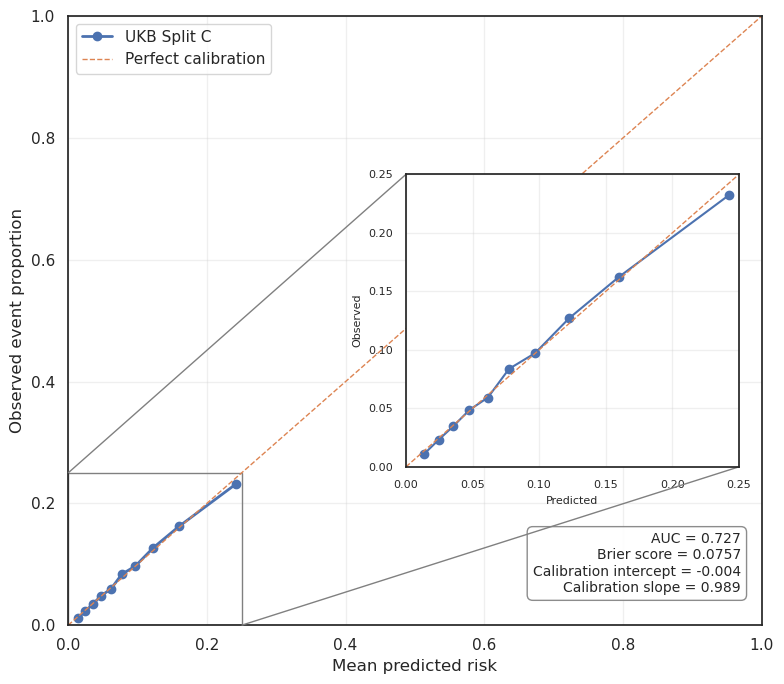

In [16]:
ukb_calibration_path = os.path.join(
    save_dir,
    "ukb_splitC_calibration.png"
)

plot_ukb_splitc_calibration(
    Y_C,
    y_test_prob,
    calibration_test,
    save_path=ukb_calibration_path,
    zoom_max=0.25
)

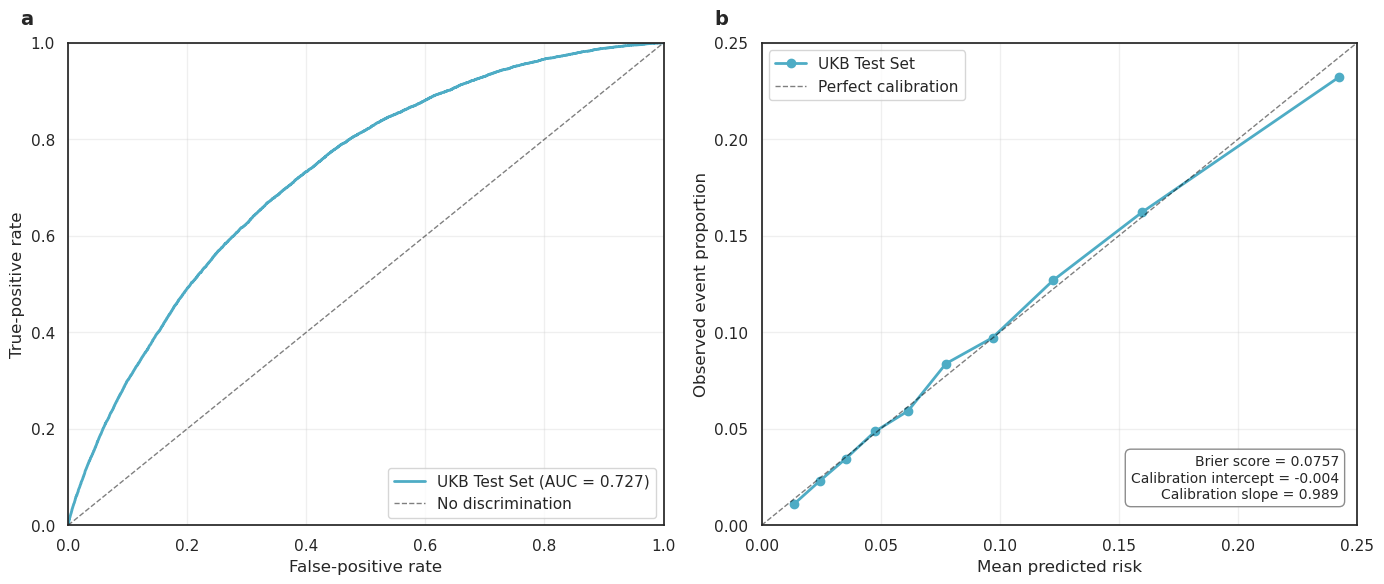

In [21]:
# Combined internal-validation figure:
# Panel A = ROC curve
# Panel B = calibration curve
# Both panels use the independent UKB Split C test set only

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: ROC curve — Split C only
fpr_test, tpr_test, _ = roc_curve(Y_C, y_test_prob)

ax1.plot(fpr_test,tpr_test,
    label=f'UKB Test Set (AUC = {calibration_test["auc"]:.3f})',
    color='#4EACC5',lw=2)

# This is a no-discrimination reference line, not a "perfect ROC curve"
ax1.plot([0, 1],[0, 1], 
    linestyle='--',color='black',
    lw=1,alpha=0.5,
    label='No discrimination')

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_xlabel('False-positive rate')
ax1.set_ylabel('True-positive rate')

ax1.text(-0.08,1.03,'a',
    transform=ax1.transAxes,fontsize=14,fontweight='bold',
    va='bottom',ha='left')

ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Panel B: Calibration curve — Split C only
frac_pos_test, mean_pred_test = calibration_curve(Y_C,y_test_prob,
    n_bins=10,strategy='quantile')

ax2.plot(mean_pred_test,frac_pos_test,
    marker='o',linestyle='-',
    color='#4EACC5',lw=2,label='UKB Test Set')

ax2.plot([0, 0.25],[0, 0.25],
    linestyle='--',color='black',
    lw=1,alpha=0.5,label='Perfect calibration')

# Focus on the range containing the observed predictions
ax2.set_xlim(0, 0.25)
ax2.set_ylim(0, 0.25)

ax2.set_xticks(np.arange(0, 0.251, 0.05))
ax2.set_yticks(np.arange(0, 0.251, 0.05))

ax2.set_xlabel('Mean predicted risk')
ax2.set_ylabel('Observed event proportion')

ax2.text(-0.08,1.03,'b',
    transform=ax2.transAxes,fontsize=14,
    fontweight='bold',va='bottom',ha='left')

# Performance metrics
metric_text = (f'Brier score = {calibration_test["brier"]:.4f}\n'
    f'Calibration intercept = {calibration_test["intercept"]:.3f}\n'
    f'Calibration slope = {calibration_test["slope"]:.3f}')

ax2.text(0.97,0.05,metric_text,
    transform=ax2.transAxes,ha='right',va='bottom',fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4',facecolor='white',edgecolor='grey',alpha=0.9))

ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Save and display
plt.tight_layout()
combined_validation_path = os.path.join(save_dir,'ukb_splitC_roc_calibration.png')

plt.savefig(combined_validation_path,dpi=300,bbox_inches='tight')
plt.show()

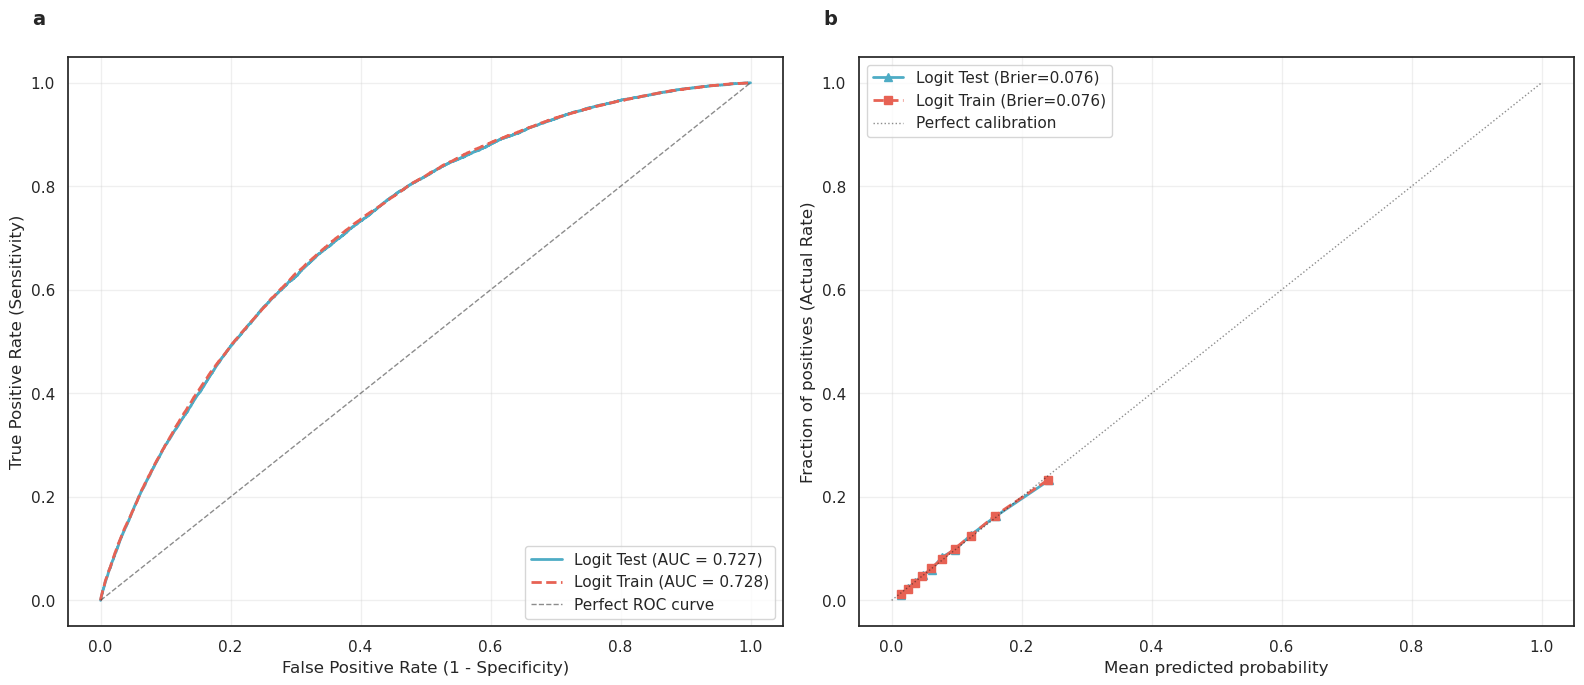

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Roc curve: Logistic Regression (Test set vs )
fpr_test, tpr_test, _ = roc_curve(Y_C, y_test_prob)
fpr_train, tpr_train, _ = roc_curve(Y_B, y_train_prob)

ax1.plot(fpr_test, tpr_test, label=f'Logit Test (AUC = {test_auc_logit:.3f})', color='#4EACC5', lw=2)
ax1.plot(fpr_train, tpr_train, label=f'Logit Train (AUC = {train_auc_logit:.3f})', color='#E76254', lw=2, linestyle='--')

ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect ROC curve', alpha=0.5)
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
#ax1.set_title('ROC Curve Comparison (Test vs Train)')
ax1.text(-0.05, 1.05, 'a', transform=ax1.transAxes,
        fontsize=14, fontweight='bold', va='bottom', ha='left')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)


# Calibration curve: Logistic Regression (Test set vs Train set)
frac_pos_test, mean_pred_test = calibration_curve(Y_C, y_test_prob, n_bins=10, strategy='quantile')
frac_pos_train, mean_pred_train = calibration_curve(Y_B, y_train_prob, n_bins=10, strategy='quantile')

ax2.plot(mean_pred_test, frac_pos_test, '^-', label=f'Logit Test (Brier={brier_score_loss(Y_C, y_test_prob):.3f})', color='#4EACC5', lw=2)
ax2.plot(mean_pred_train, frac_pos_train, 's--', label=f'Logit Train (Brier={brier_score_loss(Y_B, y_train_prob):.3f})', color='#E76254', lw=2)

ax2.plot([0, 1], [0, 1], 'k:', lw=1, label='Perfect calibration', alpha=0.5)
ax2.set_xlabel('Mean predicted probability')
ax2.set_ylabel('Fraction of positives (Actual Rate)')
#ax2.set_title('Calibration Curve Comparison(Test vs Train)')
ax2.text(-0.05, 1.05, 'b', transform=ax2.transAxes,
         fontsize=14, fontweight='bold', va='bottom', ha='left')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

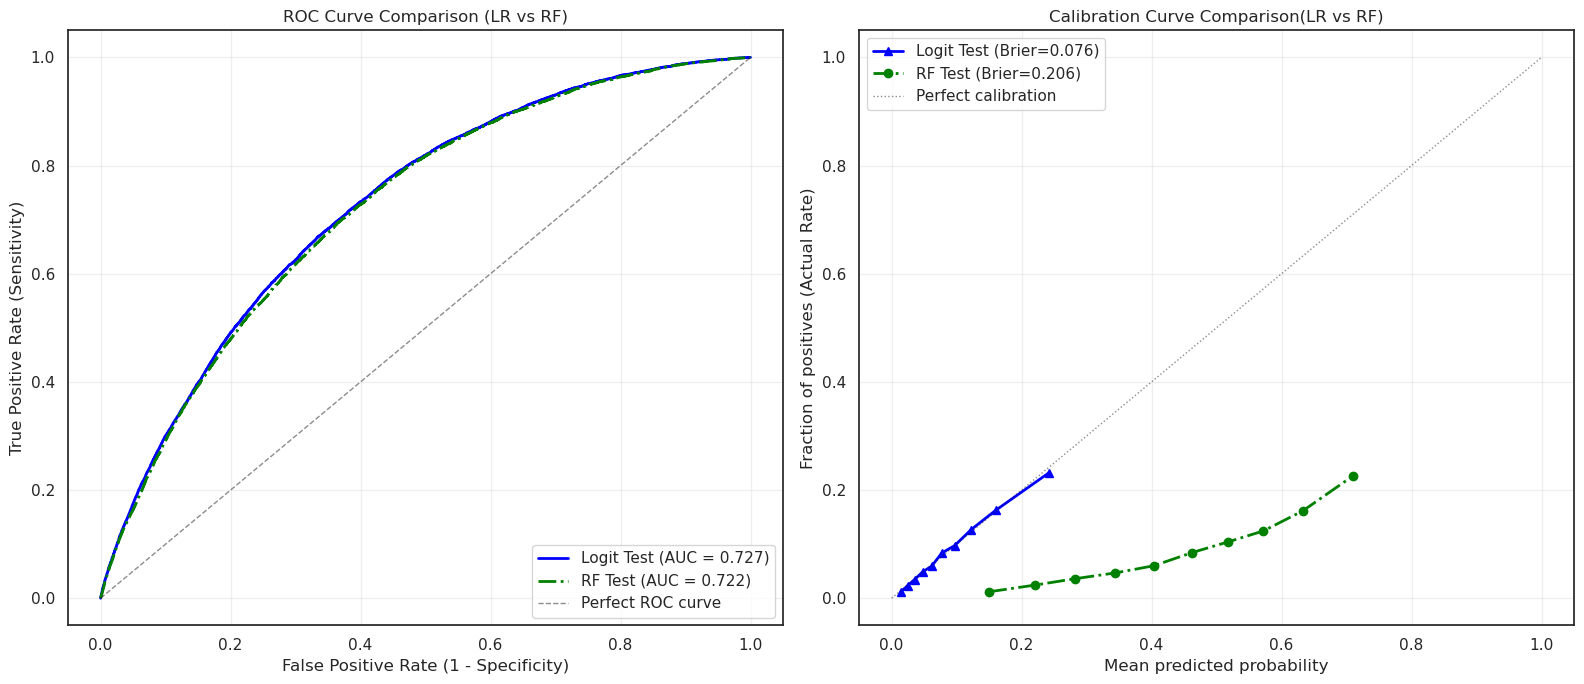

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Roc curve: Logistic Regression vs Random Forest
fpr_test, tpr_test, _ = roc_curve(Y_C, y_test_prob)
fpr_rf_test, tpr_rf_test, _ = roc_curve(Y_C, y_pred_prob_rf)

ax1.plot(fpr_test, tpr_test, label=f'Logit Test (AUC = {test_auc_logit:.3f})', color='blue', lw=2)
ax1.plot(fpr_rf_test, tpr_rf_test, label=f'RF Test (AUC = {auc_rf:.3f})', color='green', lw=2, linestyle='-.')

ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect ROC curve', alpha=0.5)
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title('ROC Curve Comparison (LR vs RF)')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)


# Calibration curve: Logistic Regression vs Random Forest
frac_pos_test, mean_pred_test = calibration_curve(Y_C, y_test_prob, n_bins=10, strategy='quantile')
frac_pos_rf, mean_pred_rf = calibration_curve(Y_C, y_pred_prob_rf, n_bins=10, strategy='quantile')

ax2.plot(mean_pred_test, frac_pos_test, '^-', label=f'Logit Test (Brier={brier_score_loss(Y_C, y_test_prob):.3f})', color='blue', lw=2)
ax2.plot(mean_pred_rf, frac_pos_rf, 'o-.', label=f'RF Test (Brier={brier_score_loss(Y_C, y_pred_prob_rf):.3f})', color='green', lw=2)

ax2.plot([0, 1], [0, 1], 'k:', lw=1, label='Perfect calibration', alpha=0.5)
ax2.set_xlabel('Mean predicted probability')
ax2.set_ylabel('Fraction of positives (Actual Rate)')
ax2.set_title('Calibration Curve Comparison(LR vs RF)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

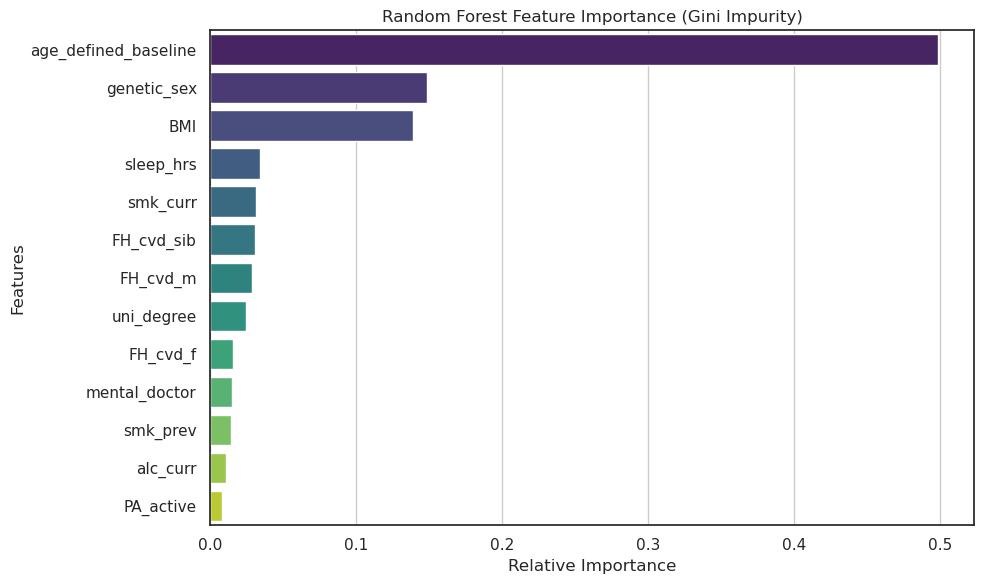

In [15]:
# supplementary figure: feature importance from random forest
rf_importances = rf_model.feature_importances_

rf_imp_df = pd.DataFrame({ 
    'Feature': final_features,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False) # create a DataFrame for feature importance and sort by importance

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=rf_imp_df, palette='viridis', legend=False)
plt.title('Random Forest Feature Importance (Gini Impurity)')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [23]:
np.save(os.path.join(save_dir, "splitC_y_true.npy"), np.asarray(Y_C, dtype=int))
np.save(os.path.join(save_dir, "splitC_pred_prob.npy"), np.asarray(y_test_prob, dtype=float))

splitC_metrics = pd.DataFrame([{
    "dataset": "UKB Split C",
    "n": len(Y_C),
    "events": int(np.sum(Y_C)),
    "event_rate": float(np.mean(Y_C)),
    "mean_predicted_risk": calibration_test["mean_predicted"],
    "auc": calibration_test["auc"],
    "brier_score": calibration_test["brier"],
    "calibration_intercept": calibration_test["intercept"],
    "calibration_intercept_ci_low": calibration_test["intercept_ci_low"],
    "calibration_intercept_ci_high": calibration_test["intercept_ci_high"],
    "calibration_slope": calibration_test["slope"],
    "calibration_slope_ci_low": calibration_test["slope_ci_low"],
    "calibration_slope_ci_high": calibration_test["slope_ci_high"]
}])

splitC_metrics.to_csv(os.path.join(save_dir, "splitC_validation_metrics.csv"), index=False)

fpr_test, tpr_test, _ = roc_curve(Y_C, y_test_prob)
frac_pos_test, mean_pred_test = calibration_curve(Y_C, y_test_prob, n_bins=10, strategy="quantile")

np.save(os.path.join(save_dir, "splitC_fpr.npy"), fpr_test)
np.save(os.path.join(save_dir, "splitC_tpr.npy"), tpr_test)
np.save(os.path.join(save_dir, "splitC_cal_mean_pred.npy"), mean_pred_test)
np.save(os.path.join(save_dir, "splitC_cal_frac_pos.npy"), frac_pos_test)

print("Saved Split C predictions, metrics, ROC arrays and calibration arrays.")

Saved Split C predictions, metrics, ROC arrays and calibration arrays.


In [16]:
# Export Split C ROC + calibration data for use in HRS comparison plot
fpr_test, tpr_test, _ = roc_curve(Y_C, y_test_prob)
frac_pos_test, mean_pred_test = calibration_curve(
    Y_C, y_test_prob, n_bins=10, strategy='quantile'
)

save_dir = os.path.join(SAVE_DIR, '../external_validation_hrs/outputs')

np.save(os.path.join(save_dir, 'splitC_fpr.npy'), fpr_test)
np.save(os.path.join(save_dir, 'splitC_tpr.npy'), tpr_test)
np.save(os.path.join(save_dir, 'splitC_cal_mean_pred.npy'), mean_pred_test)
np.save(os.path.join(save_dir, 'splitC_cal_frac_pos.npy'), frac_pos_test)

brier_c = brier_score_loss(Y_C, y_test_prob)
print(f"Brier (Split C): {brier_c:.4f}")
print("Saved ROC and calibration arrays for Split C")

Brier (Split C): 0.0757
Saved ROC and calibration arrays for Split C
